# Stim-Type Subgroup Analysis: Mixed vs Synced

Compare two stimulation subgroups (M=mixed, S=synced) using LMMs.

### Analyses
1. **Group x Condition**: Does the stim ON/OFF effect differ between M and S?
2. **Cumulative effect**: Does the condition x block_index interaction differ by stim type?
3. **Immediate effect**: Does the percent change at block transitions differ by stim type?

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(style='white', context='talk')

# Stim-type mapping (510 in table = 5107 in data)
STIM_TYPE = {
    '485':'M', '486':'S', '487':'S', '488':'S',
    '497':'M', '498':'S', '499':'M', '505':'M',
    '5107':'M', '515':'S', '520':'S', '545':'S'
}

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

print('Setup done.')
print(f'Mixed (M): {sorted(k for k,v in STIM_TYPE.items() if v=="M")}')
print(f'Synced (S): {sorted(k for k,v in STIM_TYPE.items() if v=="S")}')

Setup done.
Mixed (M): ['485', '497', '499', '505', '5107']
Synced (S): ['486', '487', '488', '498', '515', '520', '545']


## 1. Load & reshape data

In [2]:
def load_and_melt(path, value_name):
    df = pd.read_csv(path)
    block_cols = [c for c in df.columns if c != 'Subject_ID']
    long = df.melt(id_vars='Subject_ID', value_vars=block_cols,
                   var_name='block_label', value_name=value_name)
    long = long.dropna(subset=[value_name]).copy()
    long['block_number'] = long['block_label'].apply(
        lambda x: 0 if x == 'BL' else int(x.split('_')[1]))
    def _type(label):
        if label == 'BL': return 'baseline'
        num = int(label.split('_')[1])
        return 'stim' if num % 2 == 1 else 'pause'
    long['block_type'] = long['block_label'].apply(_type)
    long['Subject_ID'] = long['Subject_ID'].astype(str)
    long = long.sort_values(['Subject_ID', 'block_number']).reset_index(drop=True)
    # Add stim_type
    long['stim_type'] = long['Subject_ID'].map(STIM_TYPE)
    return long

df_rate = load_and_melt('final_firing_rates_wide.csv', 'firing_rate')
df_amp  = load_and_melt('final_amplitudes_wide.csv',  'amplitude')

print(f'Rate shape: {df_rate.shape}')
print(f'Amp  shape: {df_amp.shape}')
print(f'\nSubjects per stim type (rate):')
print(df_rate.groupby('stim_type')['Subject_ID'].nunique())

Rate shape: (172, 6)
Amp  shape: (171, 6)

Subjects per stim type (rate):
stim_type
M    5
S    7
Name: Subject_ID, dtype: int64


## 2. Helper functions

In [3]:
def fit_lmm(formula, data, groups_col='Subject_ID'):
    model = smf.mixedlm(formula, data=data, groups=data[groups_col])
    return model.fit(reml=True)

def print_model(result, title=''):
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(result.summary())
    print()

def extract_row(model_id, measure, result, key_coef):
    coef = result.fe_params.get(key_coef, np.nan)
    p = result.pvalues.get(key_coef, np.nan)
    ci = result.conf_int().loc[key_coef] if key_coef in result.conf_int().index else [np.nan, np.nan]
    return {
        'Model': model_id, 'Measure': measure, 'Coefficient': key_coef,
        'Estimate': round(coef, 4), 'SE': round(result.bse.get(key_coef, np.nan), 4),
        'p-value': round(p, 4), 'Sig.': p_to_stars(p),
        'CI_low': round(ci[0], 4), 'CI_high': round(ci[1], 4),
        'N_obs': int(result.nobs),
    }

---
## 3. Analysis 1: Stim-Type × Condition (ON vs OFF)

Model: `DV ~ stim_type * is_stim + block_number`, random intercept per subject.

Tests whether the ON/OFF stimulation effect differs between Mixed and Synced groups.

In [4]:
rows = []

for dv, label, df in [('firing_rate', 'Rate', df_rate), ('amplitude', 'Amp', df_amp)]:
    # Keep only stim & pause blocks
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    data['is_stim'] = (data['block_type'] == 'stim').astype(int)
    data['is_synced'] = (data['stim_type'] == 'S').astype(int)

    # Model with interaction + block_number covariate
    formula = f'{dv} ~ is_synced * is_stim + block_number'
    res = fit_lmm(formula, data)
    print_model(res, f'{label} – Stim-Type × Condition')

    rows.append(extract_row('1: Type×Cond', label, res, 'is_synced'))
    rows.append(extract_row('1: Type×Cond', label, res, 'is_stim'))
    rows.append(extract_row('1: Type×Cond', label, res, 'is_synced:is_stim'))
    rows.append(extract_row('1: Type×Cond', label, res, 'block_number'))

print('\n--- Analysis 1 Summary ---')
display(pd.DataFrame(rows))

Rate – Stim-Type × Condition
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  firing_rate
No. Observations:    162      Method:              REML       
No. Groups:          12       Scale:               17.2972    
Min. group size:     8        Log-Likelihood:      -480.1494  
Max. group size:     30       Converged:           Yes        
Mean group size:     13.5                                     
--------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------
Intercept          13.267    4.886  2.715 0.007   3.690 22.845
is_synced          -5.802    6.366 -0.911 0.362 -18.279  6.675
is_stim            -3.481    0.969 -3.593 0.000  -5.380 -1.582
is_synced:is_stim   3.267    1.312  2.490 0.013   0.696  5.838
block_number       -0.151    0.061 -2.456 0.014  -0.271 -0.030
Group Var         115.430   12.949     

,Model,Measure,Coefficient,Estimate,SE,p-value,Sig.,CI_low,CI_high,N_obs
0,1: Type×Cond,Rate,is_synced,-5.8021,6.3658,0.3621,n.s.,-18.2789,6.6747,162
1,1: Type×Cond,Rate,is_stim,-3.4808,0.9689,0.0003,***,-5.3798,-1.5818,162
2,1: Type×Cond,Rate,is_synced:is_stim,3.2669,1.3120,0.0128,*,0.6956,5.8383,162
3,1: Type×Cond,Rate,block_number,-0.1509,0.0614,0.0140,*,-0.2713,-0.0305,162
4,1: Type×Cond,Amp,is_synced,0.5330,0.6438,0.4077,n.s.,-0.7287,1.7947,161
5,1: Type×Cond,Amp,is_stim,-0.3315,0.1557,0.0332,*,-0.6367,-0.0264,161
6,1: Type×Cond,Amp,is_synced:is_stim,0.2618,0.2103,0.2132,n.s.,-0.1504,0.6739,161
7,1: Type×Cond,Amp,block_number,-0.0247,0.0098,0.0118,*,-0.0440,-0.0055,161


In [11]:
data

,Subject_ID,block_label,amplitude,block_number,block_type,stim_type,prev_value,pct_change,is_stim,is_synced
1,485,Block_1,3.397493,1,stim,M,4.844971,-29.875885,1,0
2,485,Block_2,3.726531,2,pause,M,3.397493,9.684734,0,0
3,485,Block_3,4.994247,3,stim,M,3.726531,34.018656,1,0
4,485,Block_4,3.772729,4,pause,M,4.994247,-24.458502,0,0
5,485,Block_5,2.303360,5,stim,M,3.772729,-38.947102,1,0
...,...,...,...,...,...,...,...,...,...,...
166,545,Block_6,4.165183,6,pause,S,3.905629,6.645644,0,1
167,545,Block_7,5.031972,7,stim,S,4.165183,20.810349,1,1
168,545,Block_8,2.591881,8,pause,S,5.031972,-48.491745,0,1
169,545,Block_9,7.080193,9,stim,S,2.591881,173.168149,1,1


### Visualisation – Analysis 1

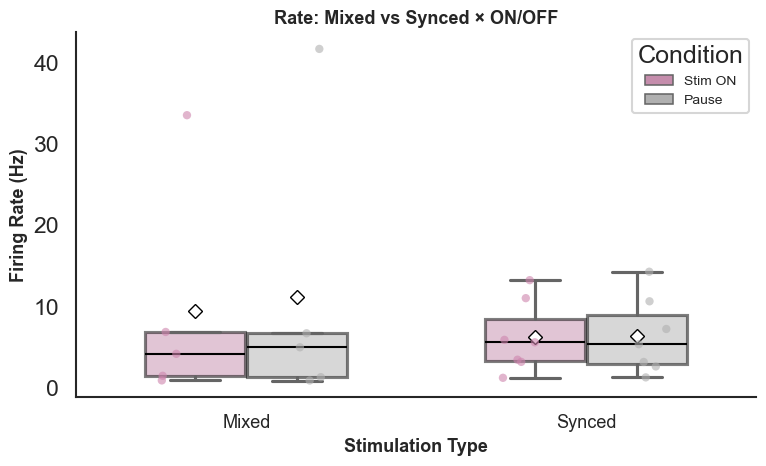

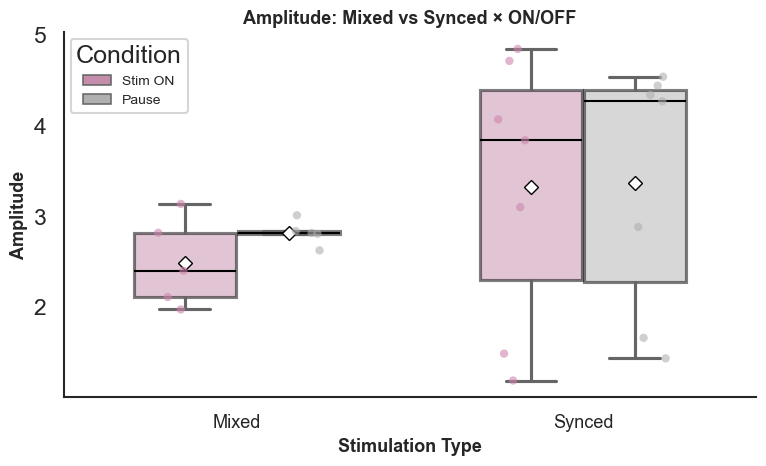

In [5]:
def plot_type_x_condition(df, dv, ylabel, title):
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    fig, ax = plt.subplots(figsize=(8, 5))
    palette = {'stim': '#ce84ad', 'pause': '#b0b0b0'}

    # Compute subject means
    subj_means = data.groupby(['Subject_ID', 'stim_type', 'block_type'])[dv].mean().reset_index()

    sns.boxplot(data=subj_means, x='stim_type', y=dv, hue='block_type',
                order=['M', 'S'], hue_order=['stim', 'pause'],
                palette=palette, width=0.6, showmeans=True,
                meanprops={'marker':'D','markerfacecolor':'white',
                           'markeredgecolor':'black','markersize':7},
                boxprops=dict(alpha=0.5, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                showfliers=False, ax=ax)
    sns.stripplot(data=subj_means, x='stim_type', y=dv, hue='block_type',
                  order=['M', 'S'], hue_order=['stim', 'pause'],
                  palette=palette, dodge=True, size=6, alpha=0.6,
                  linewidth=0, ax=ax)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], ['Stim ON', 'Pause'], title='Condition', fontsize=10)
    ax.set_xlabel('Stimulation Type', fontsize=13, fontweight='bold')
    ax.set_xticklabels(['Mixed', 'Synced'], fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()

plot_type_x_condition(df_rate, 'firing_rate', 'Firing Rate (Hz)',
                      'Rate: Mixed vs Synced × ON/OFF')
plot_type_x_condition(df_amp, 'amplitude', 'Amplitude',
                      'Amplitude: Mixed vs Synced × ON/OFF')

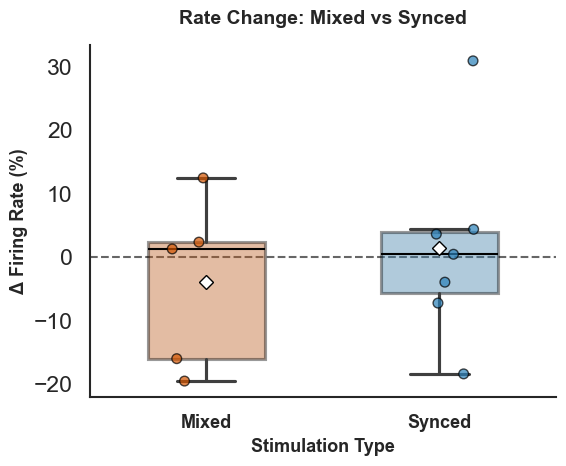

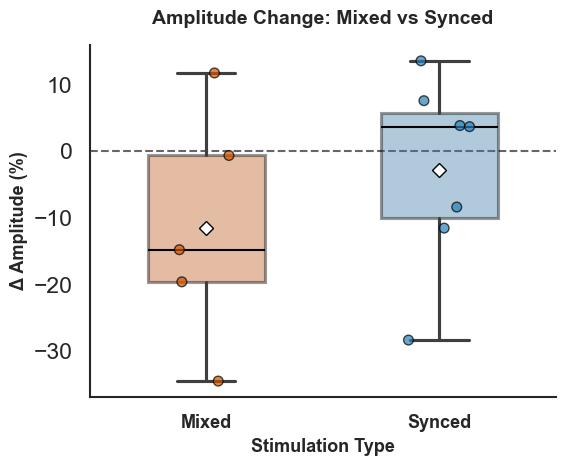

In [22]:
def plot_pct_change_by_type(df, dv, ylabel, title):
    # 1. הכנת הנתונים וחישוב ממוצע לכל נבדק בכל תנאי
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    subj_means = data.groupby(['Subject_ID', 'stim_type', 'block_type'])[dv].mean().reset_index()

    # 2. חישוב אחוז השינוי (Pivoting)
    # הופך את הטבלה כך שיהיה טור ל-stim וטור ל-pause עבור כל נבדק
    pivot_df = subj_means.pivot(index=['Subject_ID', 'stim_type'], columns='block_type', values=dv).reset_index()
    
    # חישוב אחוז השינוי
    pivot_df['pct_change'] = ((pivot_df['stim'] - pivot_df['pause']) / pivot_df['pause']) * 100
    
    # ניקוי ערכים חסרים (אם היו לנבדק נתונים רק בתנאי אחד)
    pivot_df = pivot_df.dropna(subset=['pct_change'])

    # 3. ויזואליזציה
    fig, ax = plt.subplots(figsize=(6, 5))
    palette = {'M': '#d35400', 'S': '#2980b9'} # כתום ל-Mixed, כחול ל-Synced

    # ציור בוקספלוט
    sns.boxplot(data=pivot_df, x='stim_type', y='pct_change', order=['M', 'S'],
                palette=palette, width=0.5, showmeans=True,
                meanprops={'marker':'D','markerfacecolor':'white',
                           'markeredgecolor':'black','markersize':7},
                boxprops=dict(alpha=0.4, edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                showfliers=False, ax=ax)

    # הוספת הנקודות של הנבדקים
    sns.stripplot(data=pivot_df, x='stim_type', y='pct_change', order=['M', 'S'],
                  palette=palette, size=7, alpha=0.7, jitter=0.15,
                  linewidth=1, edgecolor='black', ax=ax)

    # 4. עיצוב הצירים
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=0)
    
    ax.set_xlabel('Stimulation Type', fontsize=13, fontweight='bold')
    ax.set_xticklabels(['Mixed', 'Synced'], fontsize=13, fontweight='bold')
    ax.set_ylabel(f'Δ {ylabel} (%)', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # ניקוי ספיינס
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

# הרצה עבור הקצבים והאמפליטודות
plot_pct_change_by_type(df_rate, 'firing_rate', 'Firing Rate', 
                        'Rate Change: Mixed vs Synced')
plot_pct_change_by_type(df_amp, 'amplitude', 'Amplitude', 
                        'Amplitude Change: Mixed vs Synced')

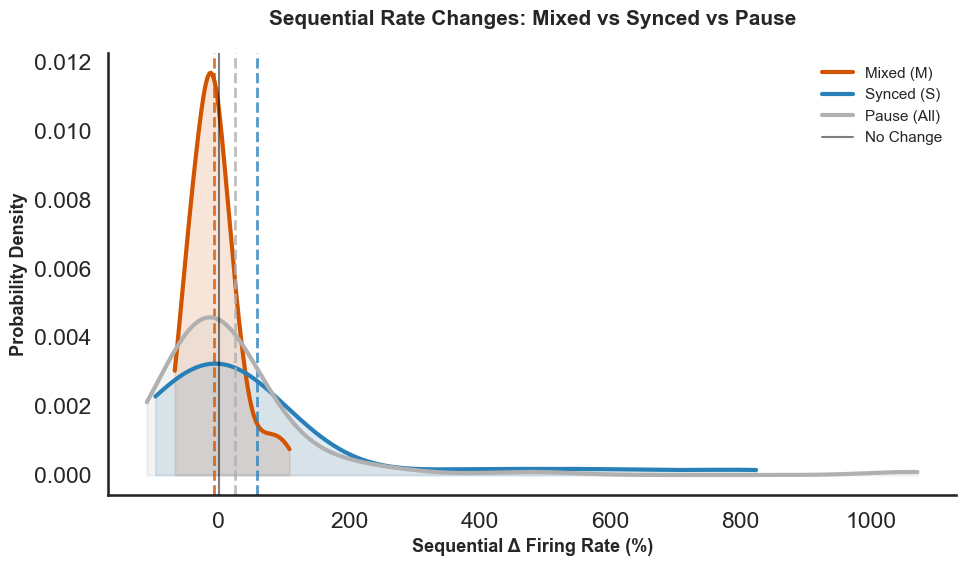

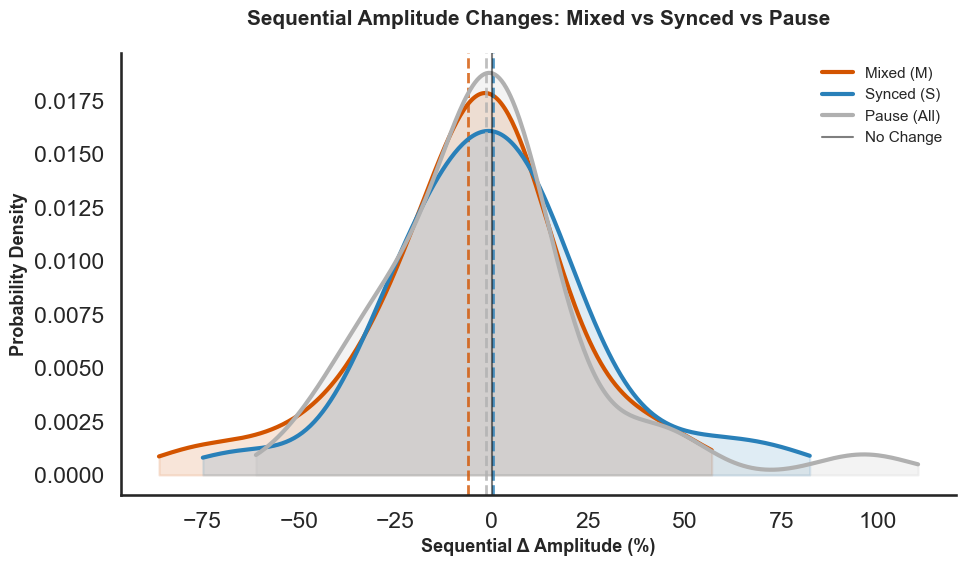

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_sequential_diff_by_group(df, dv, ylabel, title):
    # 1. הכנת הנתונים ושיוך לקבוצות (Mixed/Sync)
    stim_type_map = {
        '485': 'M', '486': 'S', '487': 'S', '488': 'S', 
        '497': 'M', '498': 'S', '499': 'M', '505': 'M', 
        '510': 'M', '520': 'S'
    }
    
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    data['group'] = data['Subject_ID'].astype(str).map(stim_type_map)
    
    # חישוב אחוז השינוי העוקב
    data['prev_val'] = data.groupby(['Subject_ID', 'block_type'])[dv].shift(1)
    data['pct_change'] = ((data[dv] - data['prev_val']) / data['prev_val']) * 100
    diff_data = data.dropna(subset=['pct_change'])

    # 2. הגדרות ויזואליות (3 קבוצות להשוואה)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # הגדרת צבעים: ורוד כהה ל-Mixed, כחול ל-Sync, אפור להפסקה (כללית)
    plot_configs = [
        {'label': 'Mixed (M)', 'color': '#d35400', 'condition': (diff_data['block_type'] == 'stim') & (diff_data['group'] == 'M')},
        {'label': 'Synced (S)', 'color': '#2980b9', 'condition': (diff_data['block_type'] == 'stim') & (diff_data['group'] == 'S')},
        {'label': 'Pause (All)', 'color': '#b0b0b0', 'condition': (diff_data['block_type'] == 'pause')}
    ]
    
    # 3. ציור ידני של ההתפלגויות
    for config in plot_configs:
        subset = diff_data[config['condition']]['pct_change'].values
        if len(subset) < 2: continue
        
        color = config['color']
        label = config['label']
        
        # חישוב KDE ידני
        kde = gaussian_kde(subset)
        x_range = np.linspace(subset.min() - 10, subset.max() + 10, 300)
        
        # ציור העקומה והשטח שמתחתיה
        ax.plot(x_range, kde(x_range), color=color, linewidth=3, label=label)
        ax.fill_between(x_range, 0, kde(x_range), color=color, alpha=0.15)
        
        # הוספת קו ממוצע אנכי
        mean_val = np.mean(subset)
        ax.axvline(mean_val, color=color, linestyle='--', linewidth=2, alpha=0.8)

    # 4. עיצוב סופי
    ax.axvline(0, color='black', linewidth=1.5, alpha=0.5, label='No Change')
    ax.set_xlabel(f'Sequential Δ {ylabel} (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.show()

# הרצה לדוגמה:
plot_sequential_diff_by_group(df_rate, 'firing_rate', 'Firing Rate', 'Sequential Rate Changes: Mixed vs Synced vs Pause')
plot_sequential_diff_by_group(df_amp, 'amplitude', 'Amplitude', 'Sequential Amplitude Changes: Mixed vs Synced vs Pause')

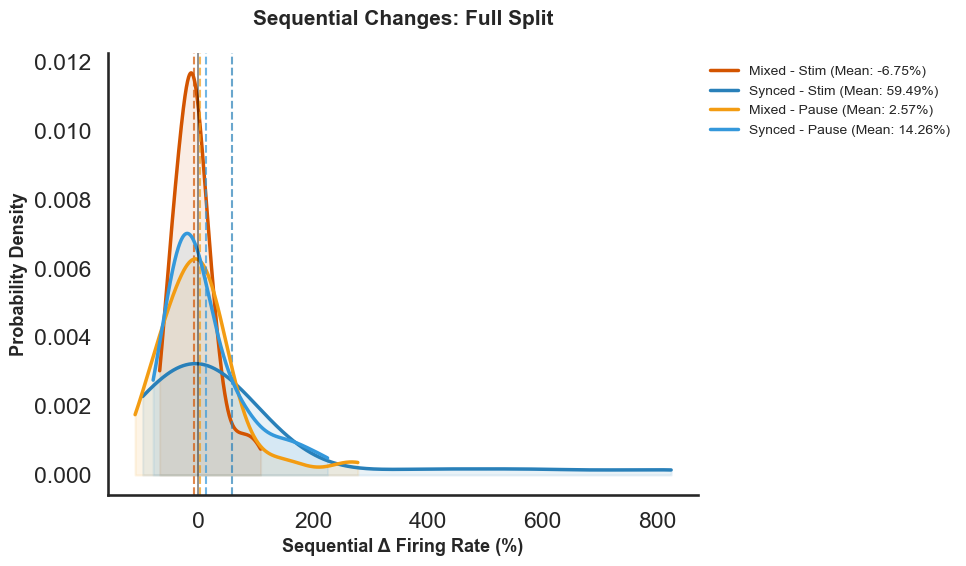

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_sequential_diff_full_split(df, dv, ylabel, title):
    # 1. מיפוי קבוצות (נשאר זהה)
    stim_type_map = {
        '485': 'M', '486': 'S', '487': 'S', '488': 'S', 
        '497': 'M', '498': 'S', '499': 'M', '505': 'M', 
        '510': 'M', '520': 'S'
    }
    
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    data['group'] = data['Subject_ID'].astype(str).map(stim_type_map)
    
    # 2. חישוב אחוז השינוי העוקב בתוך כל נבדק וסוג בלוק
    data['prev_val'] = data.groupby(['Subject_ID', 'block_type'])[dv].shift(1)
    data['pct_change'] = ((data[dv] - data['prev_val']) / data['prev_val']) * 100
    diff_data = data.dropna(subset=['pct_change'])

    # 3. הגדרת ויזואליזציה (4 קבוצות)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # הגדרת התנאים והצבעים
    plot_configs = [
        {'label': 'Mixed - Stim', 'color': '#d35400', 'cond': (diff_data['block_type'] == 'stim') & (diff_data['group'] == 'M')},
        {'label': 'Synced - Stim', 'color': '#2980b9', 'cond': (diff_data['block_type'] == 'stim') & (diff_data['group'] == 'S')},
        {'label': 'Mixed - Pause', 'color': '#f39c12', 'cond': (diff_data['block_type'] == 'pause') & (diff_data['group'] == 'M')},
        {'label': 'Synced - Pause', 'color': '#3498db', 'cond': (diff_data['block_type'] == 'pause') & (diff_data['group'] == 'S')}
    ]
    
    # 4. ציור ידני של ההתפלגויות עם הממוצעים במקרא
    for config in plot_configs:
        subset = diff_data[config['cond']]['pct_change'].values
        if len(subset) < 2: continue
        
        color = config['color']
        mean_val = np.mean(subset)
        
        # יצירת לייבל הכולל את הממוצע
        label_with_mean = f"{config['label']} (Mean: {mean_val:.2f}%)"
        
        # חישוב KDE
        kde = gaussian_kde(subset)
        # טווח ציר X מותאם לנתונים
        x_range = np.linspace(subset.min() - 10, subset.max() + 10, 500)
        
        # ציור
        ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=label_with_mean)
        ax.fill_between(x_range, 0, kde(x_range), color=color, alpha=0.1)
        
        # הוספת קו ממוצע אנכי עדין
        ax.axvline(mean_val, color=color, linestyle='--', linewidth=1.5, alpha=0.7)

    # 5. עיצוב סופי
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.5)
    ax.set_xlabel(f'Sequential Δ {ylabel} (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # מיקום המקרא מחוץ לגרף אם הוא מסתיר נתונים
    ax.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

# להרצה:
plot_sequential_diff_full_split(df_rate, 'firing_rate', 'Firing Rate', 'Sequential Changes: Full Split')

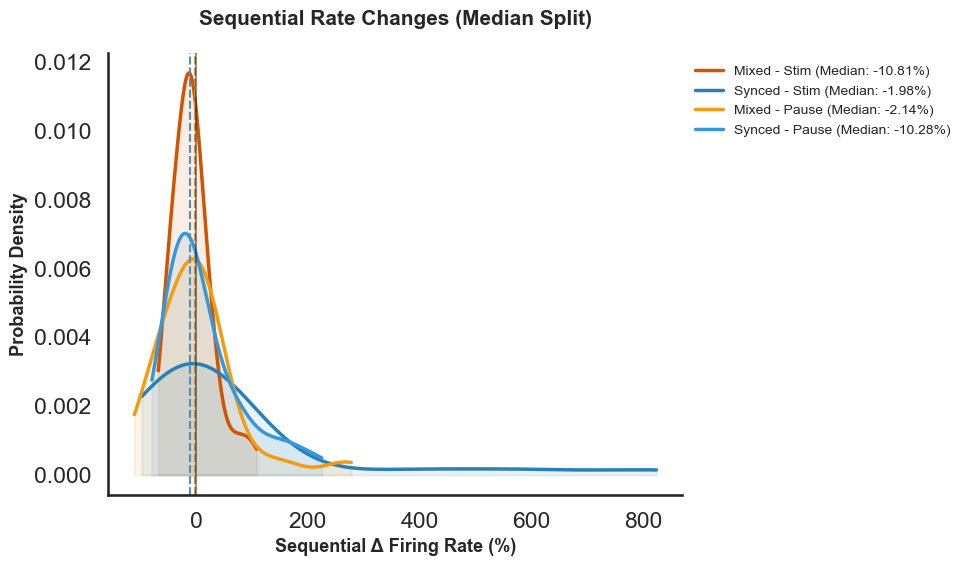

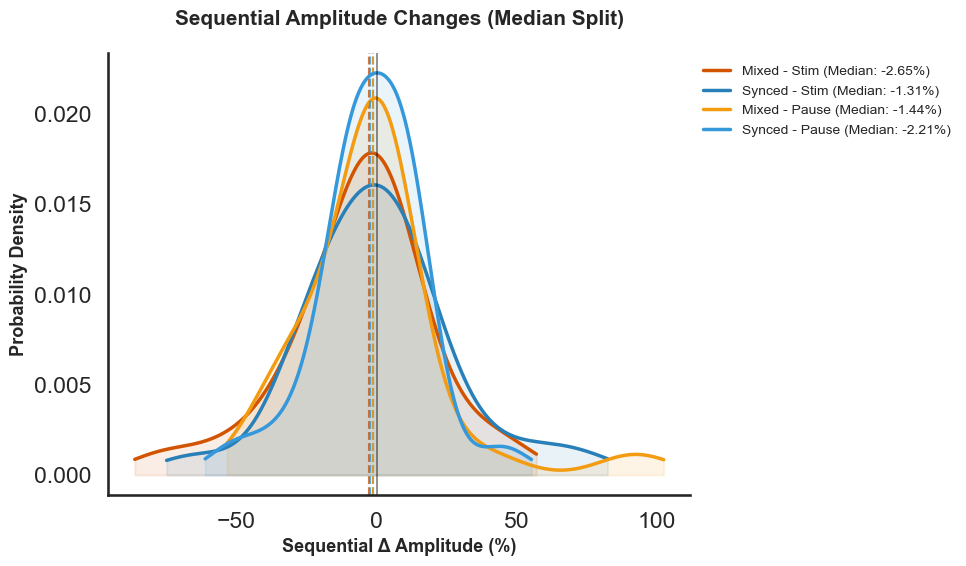

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_sequential_diff_median_split(df, dv, ylabel, title):
    # 1. מיפוי קבוצות (M=Mixed, S=Synced)
    stim_type_map = {
        '485': 'M', '486': 'S', '487': 'S', '488': 'S', 
        '497': 'M', '498': 'S', '499': 'M', '505': 'M', 
        '510': 'M', '520': 'S'
    }
    
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    data['group'] = data['Subject_ID'].astype(str).map(stim_type_map)
    
    # 2. חישוב אחוז השינוי העוקב בתוך כל נבדק וסוג בלוק
    data['prev_val'] = data.groupby(['Subject_ID', 'block_type'])[dv].shift(1)
    data['pct_change'] = ((data[dv] - data['prev_val']) / data['prev_val']) * 100
    diff_data = data.dropna(subset=['pct_change'])

    # 3. הגדרות ויזואליזציה (4 קבוצות)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    plot_configs = [
        {'label': 'Mixed - Stim', 'color': '#d35400', 'cond': (diff_data['block_type'] == 'stim') & (diff_data['group'] == 'M')},
        {'label': 'Synced - Stim', 'color': '#2980b9', 'cond': (diff_data['block_type'] == 'stim') & (diff_data['group'] == 'S')},
        {'label': 'Mixed - Pause', 'color': '#f39c12', 'cond': (diff_data['block_type'] == 'pause') & (diff_data['group'] == 'M')},
        {'label': 'Synced - Pause', 'color': '#3498db', 'cond': (diff_data['block_type'] == 'pause') & (diff_data['group'] == 'S')}
    ]
    
    # 4. ציור ההתפלגויות עם חציונים במקרא
    for config in plot_configs:
        subset = diff_data[config['cond']]['pct_change'].values
        if len(subset) < 2: continue
        
        color = config['color']
        # שימוש בחציון (Median) כדי למנוע השפעת ערכים קיצוניים
        median_val = np.median(subset)
        
        # בניית הלייבל למקרא
        label_with_median = f"{config['label']} (Median: {median_val:.2f}%)"
        
        # חישוב KDE ידני (עוקף את הבאג של Seaborn בסביבה שלך)
        kde = gaussian_kde(subset)
        x_range = np.linspace(subset.min() - 10, subset.max() + 10, 500)
        
        # ציור העקומה והשטח
        ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=label_with_median)
        ax.fill_between(x_range, 0, kde(x_range), color=color, alpha=0.1)
        
        # הוספת קו חציון אנכי
        ax.axvline(median_val, color=color, linestyle='--', linewidth=1.5, alpha=0.8)

    # 5. עיצוב סופי
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.5)
    ax.set_xlabel(f'Sequential Δ {ylabel} (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # מיקום המקרא מחוץ לגרף למניעת הסתרה
    ax.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

# --- קריאות להרצה מיידית ---
plot_sequential_diff_median_split(df_rate, 'firing_rate', 'Firing Rate', 'Sequential Rate Changes (Median Split)')
plot_sequential_diff_median_split(df_amp, 'amplitude', 'Amplitude', 'Sequential Amplitude Changes (Median Split)')

---
## 4. Analysis 2: Cumulative Effect – Condition × Block Index by Stim Type

### 2A: Three-way interaction model
`DV ~ is_stim * block_number * is_synced`

### 2B: Separate models per subgroup
Tests whether the condition × block_index interaction exists within each subgroup.

In [6]:
rows2 = []

for dv, label, df in [('firing_rate', 'Rate', df_rate), ('amplitude', 'Amp', df_amp)]:
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    data['is_stim'] = (data['block_type'] == 'stim').astype(int)
    data['is_synced'] = (data['stim_type'] == 'S').astype(int)

    # 2A: Three-way interaction
    formula_3way = f'{dv} ~ is_stim * block_number * is_synced'
    res_3way = fit_lmm(formula_3way, data)
    print_model(res_3way, f'{label} – Three-Way Interaction')

    # Extract the 3-way interaction term
    three_way_key = 'is_stim:block_number:is_synced'
    rows2.append(extract_row('2A: 3-Way', label, res_3way, three_way_key))

    # 2B: Separate per subgroup
    for stype in ['M', 'S']:
        sub = data[data['stim_type'] == stype].copy()
        formula_sub = f'{dv} ~ is_stim * block_number'
        res_sub = fit_lmm(formula_sub, sub)
        print_model(res_sub, f'{label} – Cumulative Effect ({stype} only)')
        rows2.append(extract_row(f'2B: Cumul ({stype})', label, res_sub,
                                 'is_stim:block_number'))

print('\n--- Analysis 2 Summary ---')
display(pd.DataFrame(rows2))

Rate – Three-Way Interaction
                   Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       firing_rate
No. Observations:       162           Method:                   REML       
No. Groups:             12            Scale:                    15.5194    
Min. group size:        8             Log-Likelihood:           -474.2706  
Max. group size:        30            Converged:                Yes        
Mean group size:        13.5                                               
---------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       11.668    5.045  2.313 0.021   1.780 21.557
is_stim                          1.058    1.514  0.698 0.485  -1.910  4.026
block_number                    -0.021    0.096 -0.222 0.824  -0.209  0.166
is

,Model,Measure,Coefficient,Estimate,SE,p-value,Sig.,CI_low,CI_high,N_obs
0,2A: 3-Way,Rate,is_stim:block_number:is_synced,0.4106,0.1950,0.0353,*,0.0284,0.7928,162
1,2B: Cumul (M),Rate,is_stim:block_number,-0.4595,0.1381,0.0009,***,-0.7301,-0.1889,74
2,2B: Cumul (S),Rate,is_stim:block_number,-0.0489,0.1302,0.7070,n.s.,-0.3042,0.2063,88
3,2A: 3-Way,Amp,is_stim:block_number:is_synced,0.0262,0.0331,0.4289,n.s.,-0.0387,0.0911,161
4,2B: Cumul (M),Amp,is_stim:block_number,0.0016,0.0185,0.9333,n.s.,-0.0347,0.0378,73
5,2B: Cumul (S),Amp,is_stim:block_number,0.0280,0.0279,0.3166,n.s.,-0.0268,0.0827,88


### Visualisation – Cumulative Effect by Subgroup

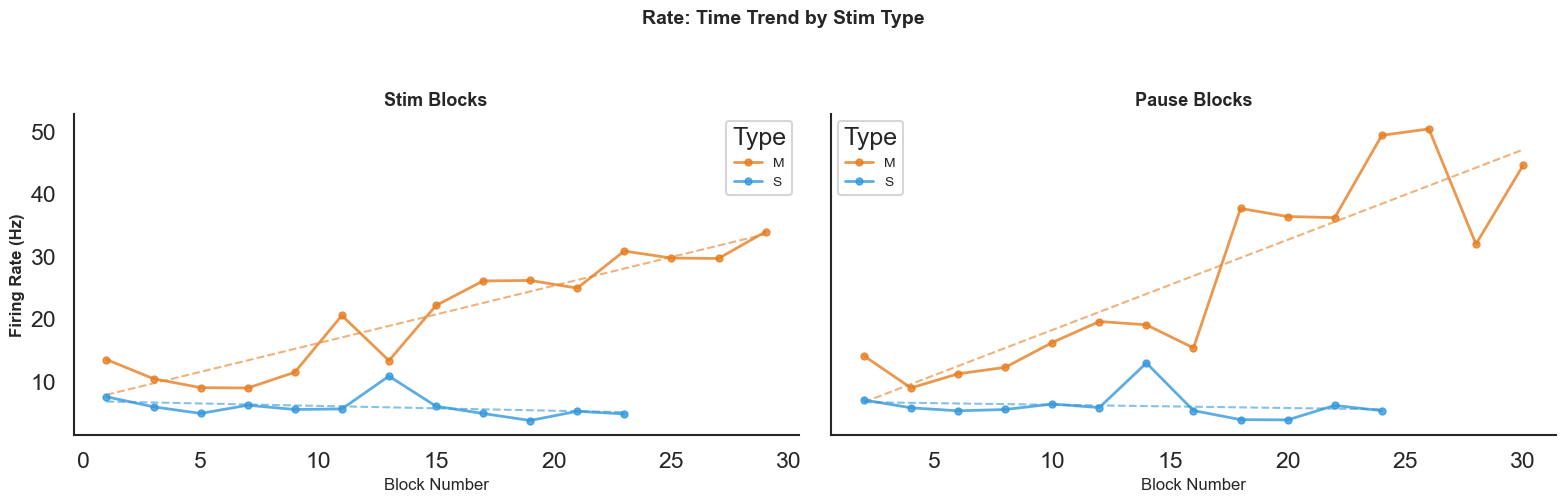

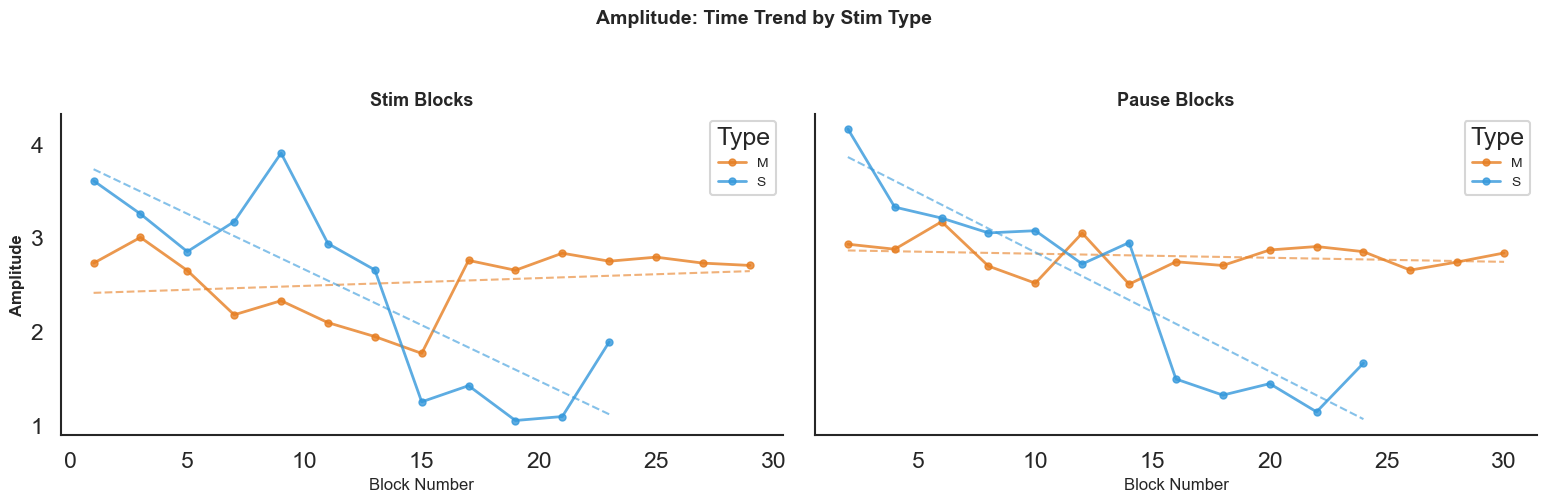

In [7]:
def plot_cumulative_by_type(df, dv, ylabel, title):
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    palette_type = {'M': '#e67e22', 'S': '#3498db'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for idx, cond in enumerate(['stim', 'pause']):
        ax = axes[idx]
        sub = data[data['block_type'] == cond]

        for stype, color in palette_type.items():
            grp = sub[sub['stim_type'] == stype]
            means = grp.groupby('block_number')[dv].mean()
            ax.plot(means.index, means.values, color=color, marker='o',
                    markersize=5, linewidth=2, label=stype, alpha=0.8)
            # Add regression line
            if len(means) > 1:
                from scipy.stats import linregress
                r = linregress(means.index, means.values)
                x_fit = np.linspace(means.index.min(), means.index.max(), 50)
                ax.plot(x_fit, r.intercept + r.slope * x_fit,
                        color=color, linewidth=1.5, linestyle='--', alpha=0.6)

        ax.set_title(f'{cond.capitalize()} Blocks', fontsize=13, fontweight='bold')
        ax.set_xlabel('Block Number', fontsize=12)
        if idx == 0:
            ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.legend(title='Type', fontsize=10)
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_cumulative_by_type(df_rate, 'firing_rate', 'Firing Rate (Hz)',
                        'Rate: Time Trend by Stim Type')
plot_cumulative_by_type(df_amp, 'amplitude', 'Amplitude',
                        'Amplitude: Time Trend by Stim Type')

---
## 5. Analysis 3: Immediate Effect (Percent Change) by Stim Type

Compute block-to-block percent change, then test whether the immediate
ON/OFF transitions differ between M and S groups.

In [8]:
def compute_pct_change(df, dv):
    out = df.sort_values(['Subject_ID', 'block_number']).copy()
    out['prev_value'] = out.groupby('Subject_ID')[dv].shift(1)
    out['pct_change'] = ((out[dv] - out['prev_value']) / out['prev_value']) * 100
    out = out.dropna(subset=['pct_change'])
    out = out[np.isfinite(out['pct_change'])].copy()
    return out

df_rate_pct = compute_pct_change(df_rate, 'firing_rate')
df_amp_pct  = compute_pct_change(df_amp,  'amplitude')

rows3 = []

for dv_label, df_pct in [('Rate', df_rate_pct), ('Amp', df_amp_pct)]:
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    data['is_stim'] = (data['block_type'] == 'stim').astype(int)
    data['is_synced'] = (data['stim_type'] == 'S').astype(int)

    # 3A: Does pct change differ by stim_type?
    res_3a = fit_lmm('pct_change ~ is_stim * is_synced', data)
    print_model(res_3a, f'{dv_label} – Pct Change: Type × Condition')
    rows3.append(extract_row('3A: Pct Type×Cond', dv_label, res_3a, 'is_synced'))
    rows3.append(extract_row('3A: Pct Type×Cond', dv_label, res_3a, 'is_stim'))
    rows3.append(extract_row('3A: Pct Type×Cond', dv_label, res_3a, 'is_stim:is_synced'))

    # 3B: Separate per subgroup
    for stype in ['M', 'S']:
        sub = data[data['stim_type'] == stype].copy()
        res_sub = fit_lmm('pct_change ~ is_stim', sub)
        print_model(res_sub, f'{dv_label} – Pct Change ({stype} only)')
        rows3.append(extract_row(f'3B: Pct ({stype})', dv_label, res_sub, 'is_stim'))

print('\n--- Analysis 3 Summary ---')
display(pd.DataFrame(rows3))

Rate – Pct Change: Type × Condition
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   pct_change
No. Observations:   160       Method:               REML      
No. Groups:         12        Scale:                7649.0889 
Min. group size:    8         Log-Likelihood:       -927.1095 
Max. group size:    30        Converged:            No        
Mean group size:    13.3                                      
--------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------
Intercept           9.871   15.822  0.624 0.533 -21.139 40.880
is_stim            13.343   20.334  0.656 0.512 -26.511 53.196
is_synced          12.521   20.762  0.603 0.546 -28.172 53.215
is_stim:is_synced -23.107   27.752 -0.833 0.405 -77.500 31.285
Group Var         118.033    9.262                            


Rate – Pct Change (M only)
   

,Model,Measure,Coefficient,Estimate,SE,p-value,Sig.,CI_low,CI_high,N_obs
0,3A: Pct Type×Cond,Rate,is_synced,12.5211,20.7624,0.5465,n.s.,-28.1724,53.2146,160
1,3A: Pct Type×Cond,Rate,is_stim,13.3427,20.3338,0.5117,n.s.,-26.5109,53.1962,160
2,3A: Pct Type×Cond,Rate,is_stim:is_synced,-23.1073,27.7518,0.4050,n.s.,-77.4998,31.2852,160
3,3B: Pct (M),Rate,is_stim,13.3427,20.7891,0.5210,n.s.,-27.4032,54.0885,74
4,3B: Pct (S),Rate,is_stim,-9.5585,18.4430,0.6043,n.s.,-45.7060,26.5891,86
5,3A: Pct Type×Cond,Amp,is_synced,-6.0456,7.2234,0.4026,n.s.,-20.2032,8.1120,159
6,3A: Pct Type×Cond,Amp,is_stim,-27.6209,7.2556,0.0001,***,-41.8417,-13.4001,159
7,3A: Pct Type×Cond,Amp,is_stim:is_synced,16.3280,9.8635,0.0978,n.s.,-3.0042,35.6602,159
8,3B: Pct (M),Amp,is_stim,-27.6123,6.3911,0.0000,***,-40.1386,-15.0861,73
9,3B: Pct (S),Amp,is_stim,-11.3345,7.2963,0.1203,n.s.,-25.6351,2.9661,86


### Visualisation – Immediate Effect by Subgroup

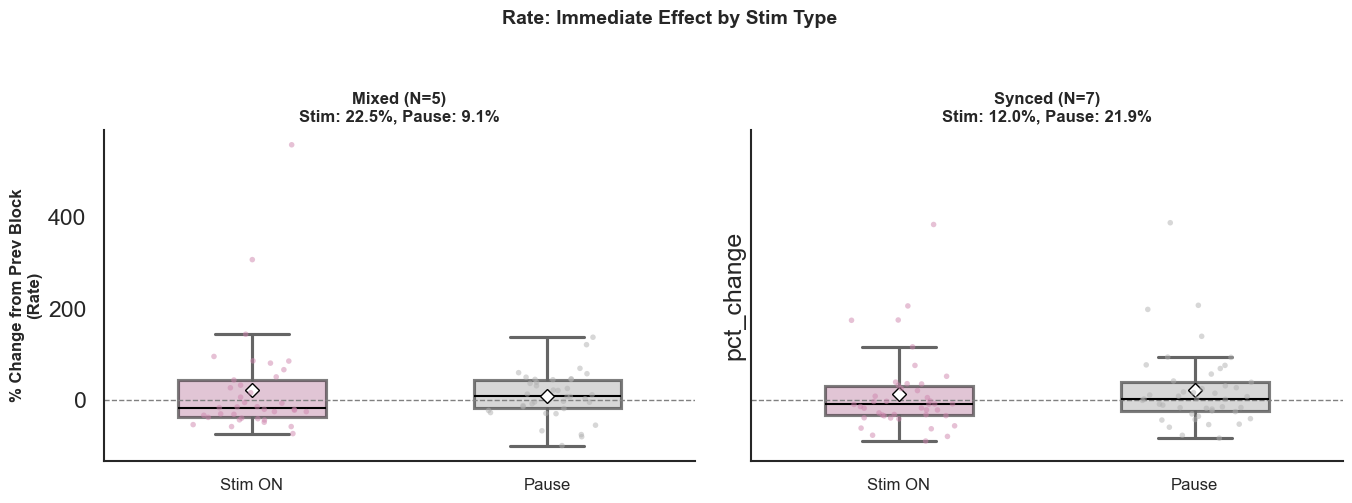

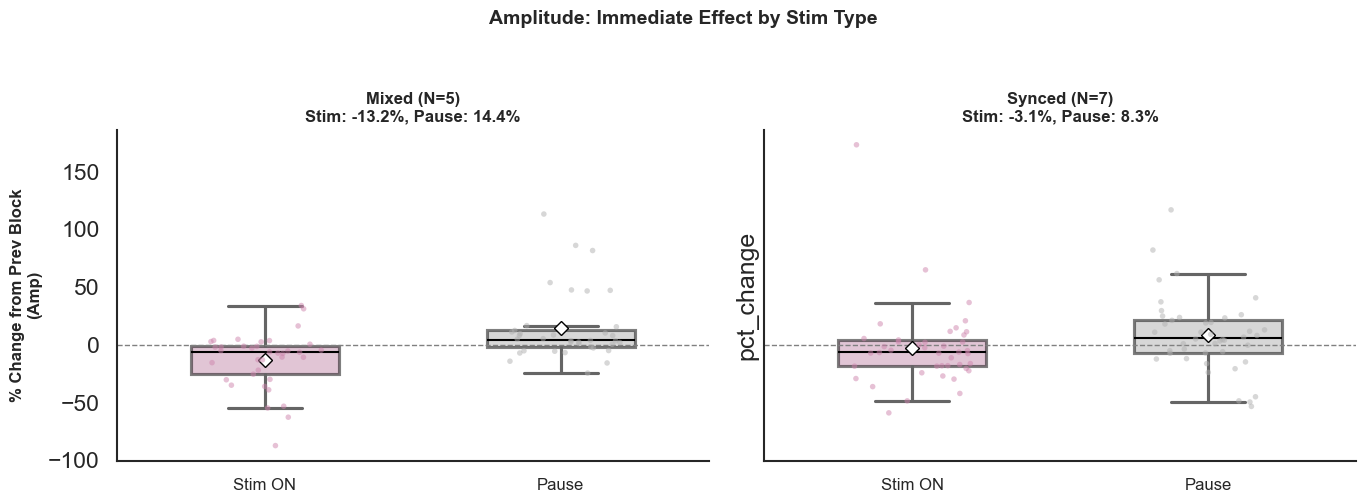

In [9]:
def plot_pct_by_type(df_pct, label, title):
    data = df_pct[df_pct['block_type'].isin(['stim', 'pause'])].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for idx, stype in enumerate(['M', 'S']):
        ax = axes[idx]
        sub = data[data['stim_type'] == stype]
        palette = {'stim': '#ce84ad', 'pause': '#b0b0b0'}

        sns.boxplot(data=sub, x='block_type', y='pct_change',
                    order=['stim', 'pause'], palette=palette, width=0.5,
                    showmeans=True,
                    meanprops={'marker':'D','markerfacecolor':'white',
                               'markeredgecolor':'black','markersize':7},
                    boxprops=dict(alpha=0.5, edgecolor='black'),
                    medianprops=dict(color='black', linewidth=1.5),
                    showfliers=False, ax=ax)
        sns.stripplot(data=sub, x='block_type', y='pct_change',
                      order=['stim', 'pause'], palette=palette,
                      size=4, alpha=0.5, linewidth=0, ax=ax, jitter=0.2)
        ax.axhline(0, color='gray', linewidth=1, linestyle='--')

        stim_mean = sub[sub['block_type']=='stim']['pct_change'].mean()
        pause_mean = sub[sub['block_type']=='pause']['pct_change'].mean()
        n_subj = sub['Subject_ID'].nunique()
        type_name = 'Mixed' if stype == 'M' else 'Synced'
        ax.set_title(f'{type_name} (N={n_subj})\n'
                     f'Stim: {stim_mean:.1f}%, Pause: {pause_mean:.1f}%',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_xticklabels(['Stim ON', 'Pause'], fontsize=12)
        if idx == 0:
            ax.set_ylabel(f'% Change from Prev Block\n({label})',
                          fontsize=12, fontweight='bold')
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_pct_by_type(df_rate_pct, 'Rate', 'Rate: Immediate Effect by Stim Type')
plot_pct_by_type(df_amp_pct, 'Amp', 'Amplitude: Immediate Effect by Stim Type')

---
## 6. Combined Summary Table

In [10]:
all_rows = rows + rows2 + rows3
df_summary = pd.DataFrame(all_rows)
display(df_summary)

df_summary.to_csv('stim_type_subgroup_analysis_summary.csv', index=False)
print('Saved to stim_type_subgroup_analysis_summary.csv')

,Model,Measure,Coefficient,Estimate,SE,p-value,Sig.,CI_low,CI_high,N_obs
0,1: Type×Cond,Rate,is_synced,-5.8021,6.3658,0.3621,n.s.,-18.2789,6.6747,162
1,1: Type×Cond,Rate,is_stim,-3.4808,0.9689,0.0003,***,-5.3798,-1.5818,162
2,1: Type×Cond,Rate,is_synced:is_stim,3.2669,1.3120,0.0128,*,0.6956,5.8383,162
3,1: Type×Cond,Rate,block_number,-0.1509,0.0614,0.0140,*,-0.2713,-0.0305,162
4,1: Type×Cond,Amp,is_synced,0.5330,0.6438,0.4077,n.s.,-0.7287,1.7947,161
5,1: Type×Cond,Amp,is_stim,-0.3315,0.1557,0.0332,*,-0.6367,-0.0264,161
6,1: Type×Cond,Amp,is_synced:is_stim,0.2618,0.2103,0.2132,n.s.,-0.1504,0.6739,161
7,1: Type×Cond,Amp,block_number,-0.0247,0.0098,0.0118,*,-0.0440,-0.0055,161
8,2A: 3-Way,Rate,is_stim:block_number:is_synced,0.4106,0.1950,0.0353,*,0.0284,0.7928,162
9,2B: Cumul (M),Rate,is_stim:block_number,-0.4595,0.1381,0.0009,***,-0.7301,-0.1889,74


Saved to stim_type_subgroup_analysis_summary.csv


---
## 7. Time Trend Visualization: % Change from Baseline by Stim Type

For each patient, compute % change from baseline at each block, then plot the
trajectory over time, split by stim type (M vs S).

- **Left panel**: Firing Rate
- **Right panel**: Amplitude

Each line = one patient. Shaded area = SEM across patients in that group.
This helps verify whether the group assignments are correct and whether
the raw/LMM results are consistent with the visual trends.

In [12]:
def plot_time_trend_by_type(df_rate, df_amp, mode='raw'):
    """
    Plot rate (left) and amplitude (right) time trends, split by stim type.

    mode: 'raw' or 'baseline_pct'
    """
    color_mixed = '#d35400'
    color_sync  = '#2980b9'
    palette = {'M': color_mixed, 'S': color_sync}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax_idx, (df, dv, ylabel_raw, ylabel_pct) in enumerate([
        (df_rate, 'firing_rate', 'Firing Rate (Hz)', 'Rate Change (%)'),
        (df_amp,  'amplitude',   'Amplitude',         'Amplitude Change (%)'),
    ]):
        ax = axes[ax_idx]
        data = df.copy()

        if mode == 'baseline_pct':
            # Only keep subjects with baseline
            subjs_with_bl = set(data[data['block_type'] == 'baseline']['Subject_ID'].unique())
            data = data[data['Subject_ID'].isin(subjs_with_bl)].copy()
            # Compute % change from baseline
            bl_vals = (data[data['block_type'] == 'baseline']
                       .groupby('Subject_ID')[dv].mean().to_dict())
            data['_bl'] = data['Subject_ID'].map(bl_vals)
            data[dv] = ((data[dv] - data['_bl']) / data['_bl']) * 100
            data = data.drop(columns='_bl')
            ylabel = ylabel_pct
        else:
            ylabel = ylabel_raw

        for stype in ['M', 'S']:
            sub = data[data['stim_type'] == stype]
            # Compute mean and SEM per block_number
            stats = sub.groupby('block_number')[dv].agg(['mean', 'std', 'count'])
            stats['sem'] = stats['std'] / np.sqrt(stats['count'])

            color = palette[stype]
            label = f'Mixed (N={sub.Subject_ID.nunique()})' if stype == 'M' else f'Sync (N={sub.Subject_ID.nunique()})'
            ax.plot(stats.index, stats['mean'], color=color, marker='o',
                    markersize=5, linewidth=2, label=label, zorder=5)
            ax.fill_between(stats.index,
                            stats['mean'] - stats['sem'],
                            stats['mean'] + stats['sem'],
                            color=color, alpha=0.2, zorder=4)

        if mode == 'baseline_pct':
            ax.axhline(y=0, color='black', linewidth=1, linestyle='-', zorder=1)

        ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.legend(frameon=False, fontsize=10)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)

    mode_title = 'Raw Values' if mode == 'raw' else '% Change from Baseline'
    fig.suptitle(f'Time Trend by Stim Type ({mode_title})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print group baselines for verification
    print(f'\n=== Verification: Per-subject baselines ({mode}) ===')
    for dv, label, df in [('firing_rate', 'Rate', df_rate), ('amplitude', 'Amp', df_amp)]:
        bl = df[df['block_type'] == 'baseline'].groupby(['Subject_ID', 'stim_type'])[dv].mean()
        if not bl.empty:
            print(f'\n{label} baselines:')
            for (subj, stype), val in bl.items():
                print(f'  {subj} ({stype}): {val:.2f}')

### Raw values

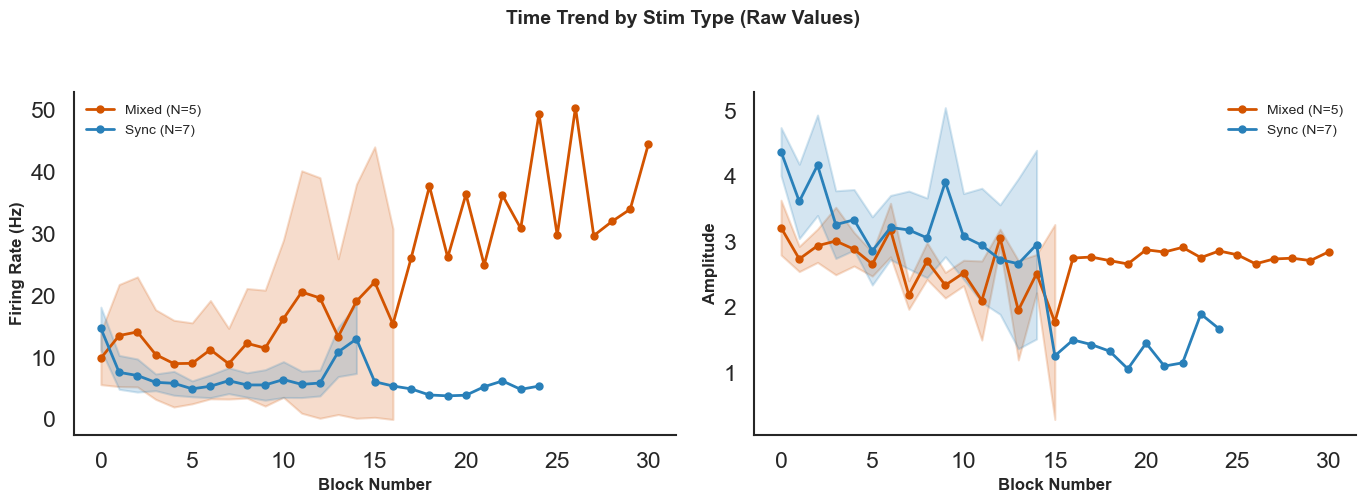


=== Verification: Per-subject baselines (raw) ===

Rate baselines:
  485 (M): 12.61
  486 (S): 6.17
  487 (S): 8.14
  488 (S): 18.94
  497 (M): 24.58
  498 (S): 15.43
  499 (M): 2.21
  505 (M): 9.53
  5107 (M): 0.67
  520 (S): 24.91

Amp baselines:
  485 (M): 4.84
  486 (S): 4.77
  487 (S): 4.70
  488 (S): 4.34
  497 (M): 2.67
  498 (S): 2.99
  499 (M): 3.14
  505 (M): 2.57
  5107 (M): 2.85
  520 (S): 5.08


In [13]:
plot_time_trend_by_type(df_rate, df_amp, mode='raw')

### % Change from Baseline

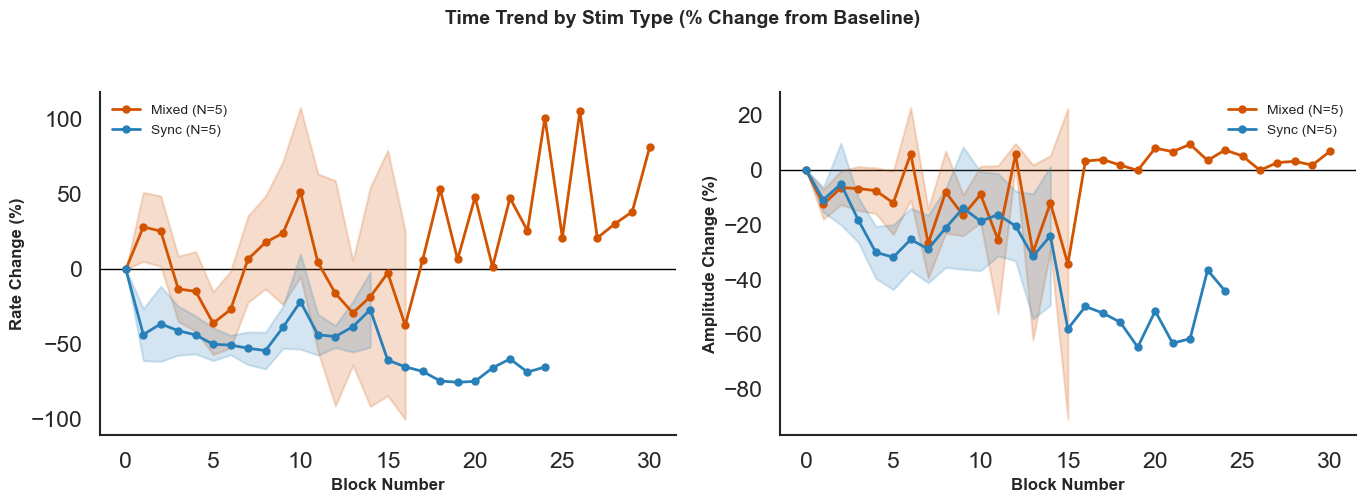


=== Verification: Per-subject baselines (baseline_pct) ===

Rate baselines:
  485 (M): 12.61
  486 (S): 6.17
  487 (S): 8.14
  488 (S): 18.94
  497 (M): 24.58
  498 (S): 15.43
  499 (M): 2.21
  505 (M): 9.53
  5107 (M): 0.67
  520 (S): 24.91

Amp baselines:
  485 (M): 4.84
  486 (S): 4.77
  487 (S): 4.70
  488 (S): 4.34
  497 (M): 2.67
  498 (S): 2.99
  499 (M): 3.14
  505 (M): 2.57
  5107 (M): 2.85
  520 (S): 5.08


In [14]:
plot_time_trend_by_type(df_rate, df_amp, mode='baseline_pct')

---
## 8. Stim vs Pause Trajectories by Group (Baseline-Normalized)

Each panel shows **two lines per group**: one for stim blocks (odd) and one
for pause blocks (even), both as % change from baseline.

This directly visualises what the LMM measures: the **gap between the stim
and pause lines** within each group. A larger gap = stronger stim-specific effect.

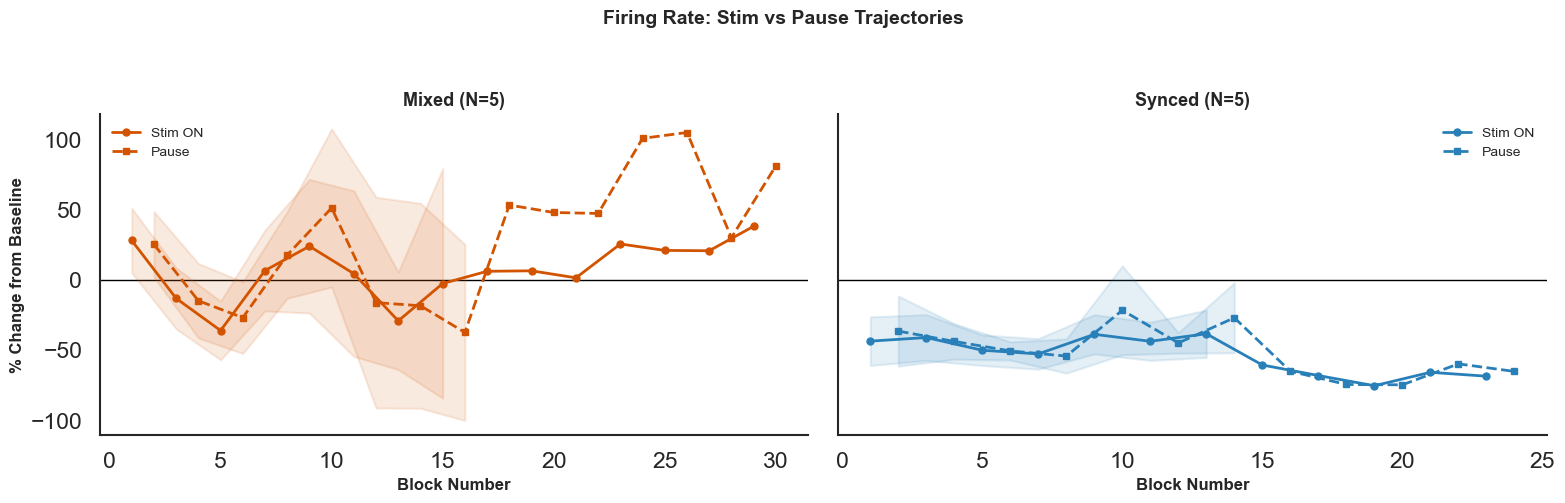

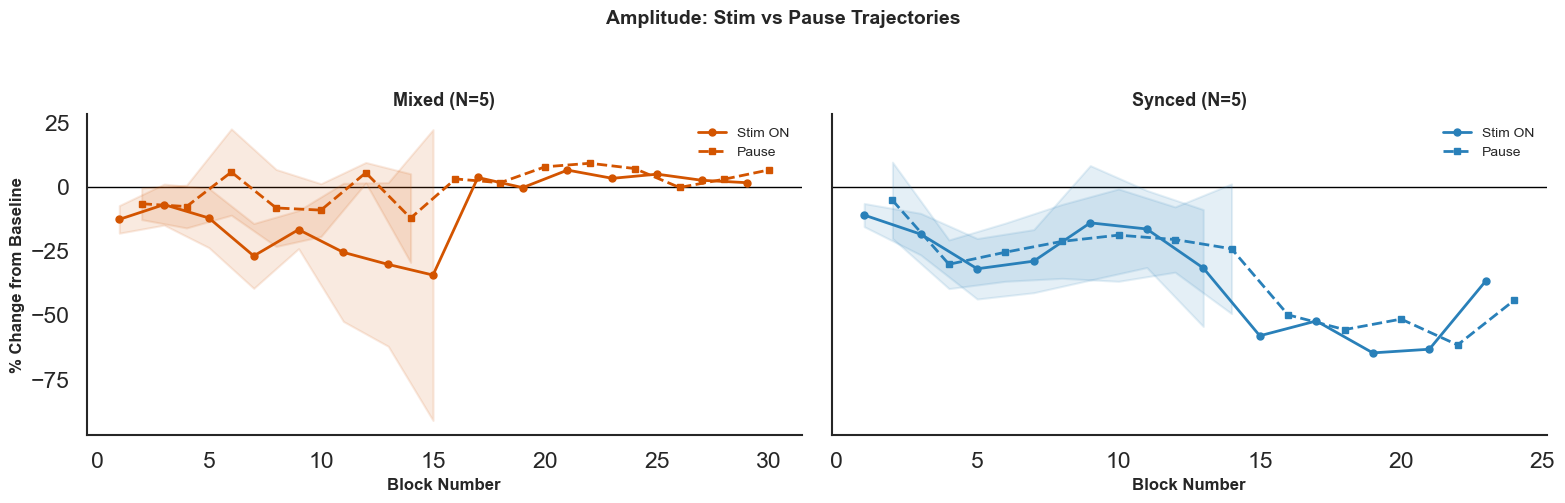

In [15]:
def plot_stim_pause_lines_by_type(df, dv, ylabel, title):
    """
    For each stim type, plot stim and pause block trajectories separately,
    both as % change from baseline.
    """
    data = df.copy()

    # Only subjects with baseline
    subjs_with_bl = set(data[data['block_type'] == 'baseline']['Subject_ID'].unique())
    data = data[data['Subject_ID'].isin(subjs_with_bl)].copy()

    # Baseline-normalize
    bl_vals = (data[data['block_type'] == 'baseline']
               .groupby('Subject_ID')[dv].mean().to_dict())
    data['_bl'] = data['Subject_ID'].map(bl_vals)
    data[dv] = ((data[dv] - data['_bl']) / data['_bl']) * 100
    data = data.drop(columns='_bl')

    # Drop baseline rows for the trajectory
    data = data[data['block_type'].isin(['stim', 'pause'])].copy()

    color_m = '#d35400'
    color_s = '#2980b9'
    ls_stim = '-'
    ls_pause = '--'

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for idx, stype in enumerate(['M', 'S']):
        ax = axes[idx]
        sub = data[data['stim_type'] == stype]
        n_subj = sub['Subject_ID'].nunique()
        color = color_m if stype == 'M' else color_s
        type_name = 'Mixed' if stype == 'M' else 'Synced'

        for bt, ls, marker, label_bt in [
            ('stim', ls_stim, 'o', 'Stim ON'),
            ('pause', ls_pause, 's', 'Pause'),
        ]:
            bt_data = sub[sub['block_type'] == bt]
            stats = bt_data.groupby('block_number')[dv].agg(['mean', 'std', 'count'])
            stats['sem'] = stats['std'] / np.sqrt(stats['count'])

            ax.plot(stats.index, stats['mean'], color=color, marker=marker,
                    markersize=5, linewidth=2, linestyle=ls, label=label_bt, zorder=5)
            ax.fill_between(stats.index,
                            stats['mean'] - stats['sem'],
                            stats['mean'] + stats['sem'],
                            color=color, alpha=0.12, zorder=3)

        ax.axhline(y=0, color='black', linewidth=1, linestyle='-', zorder=1)
        ax.set_title(f'{type_name} (N={n_subj})', fontsize=13, fontweight='bold')
        ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
        if idx == 0:
            ax.set_ylabel('% Change from Baseline', fontsize=12, fontweight='bold')
        ax.legend(frameon=False, fontsize=10)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_stim_pause_lines_by_type(df_rate, 'firing_rate',
    '% Change from Baseline', 'Firing Rate: Stim vs Pause Trajectories')

plot_stim_pause_lines_by_type(df_amp, 'amplitude',
    '% Change from Baseline', 'Amplitude: Stim vs Pause Trajectories')

---
## 9. Stim vs Pause % Change Over Time

For each block pair (stim block N and adjacent pause block N+1),
compute the **% change of stim relative to pause**: `(stim - pause) / pause × 100`,
then plot over time for each group.

- **Mixed**: the % gap should widen over time (cumulative effect)
- **Synced**: the % gap should stay flat

Mixed (N=5): gap slope = -5.458%/pair, p = 0.2062
Sync (N=7): gap slope = -4.812%/pair, p = 0.02171


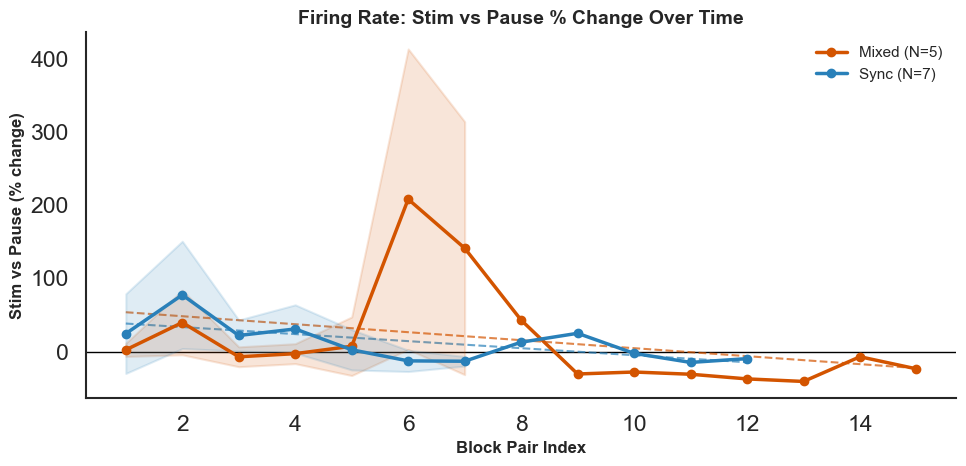

Mixed (N=5): gap slope = 0.776%/pair, p = 0.2928
Sync (N=7): gap slope = -0.374%/pair, p = 0.7689


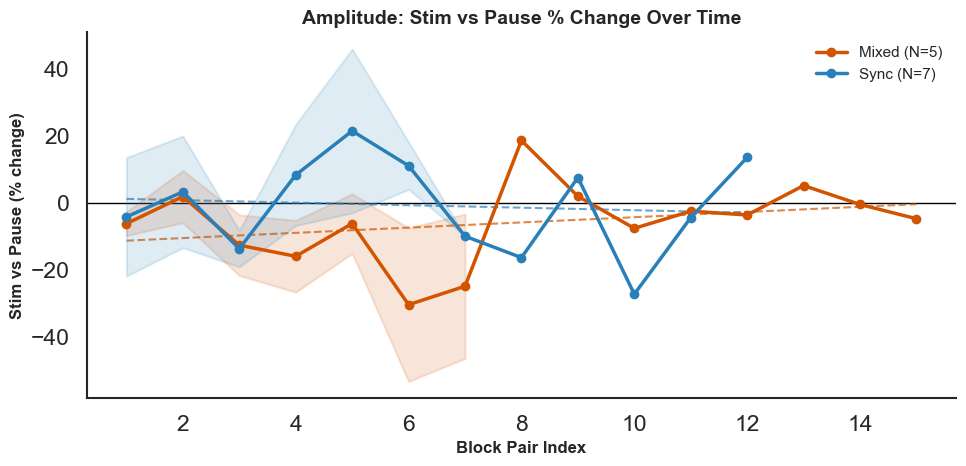

In [20]:
def plot_stim_pause_gap_over_time(df, dv, ylabel, title):
    """
    For each subject, compute % change (stim relative to adjacent pause)
    at each block pair, then average across subjects in each group.
    % change = (stim - pause) / pause * 100
    """
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    data = data.sort_values(['Subject_ID', 'block_number'])

    records = []
    for subj in data['Subject_ID'].unique():
        sub = data[data['Subject_ID'] == subj]
        stype = sub['stim_type'].iloc[0]

        stim_blocks = sub[sub['block_type'] == 'stim'].set_index('block_number')[dv]
        pause_blocks = sub[sub['block_type'] == 'pause'].set_index('block_number')[dv]

        for s_bn in stim_blocks.index:
            p_bn = s_bn + 1  # adjacent pause block
            if p_bn in pause_blocks.index and pause_blocks[p_bn] != 0:
                pct = (stim_blocks[s_bn] - pause_blocks[p_bn]) / pause_blocks[p_bn] * 100
                records.append({
                    'Subject_ID': subj, 'stim_type': stype,
                    'pair_index': (s_bn + 1) // 2,
                    'stim_vs_pause_pct': pct
                })

    df_gap = pd.DataFrame(records)

    color_m = '#d35400'
    color_s = '#2980b9'

    fig, ax = plt.subplots(figsize=(10, 5))

    for stype, color in [('M', color_m), ('S', color_s)]:
        sub = df_gap[df_gap['stim_type'] == stype]
        stats = sub.groupby('pair_index')['stim_vs_pause_pct'].agg(['mean', 'std', 'count'])
        stats['sem'] = stats['std'] / np.sqrt(stats['count'])

        n_subj = sub['Subject_ID'].nunique()
        label = f'Mixed (N={n_subj})' if stype == 'M' else f'Sync (N={n_subj})'
        ax.plot(stats.index, stats['mean'], color=color, marker='o',
                markersize=6, linewidth=2.5, label=label, zorder=5)
        ax.fill_between(stats.index,
                        stats['mean'] - stats['sem'],
                        stats['mean'] + stats['sem'],
                        color=color, alpha=0.15, zorder=3)

        # Regression line
        from scipy.stats import linregress
        if len(stats) > 1:
            r = linregress(stats.index, stats['mean'])
            x_fit = np.linspace(stats.index.min(), stats.index.max(), 50)
            ax.plot(x_fit, r.intercept + r.slope * x_fit,
                    color=color, linewidth=1.5, linestyle='--', alpha=0.7)
            print(f'{label}: gap slope = {r.slope:.3f}%/pair, p = {r.pvalue:.4g}')

    ax.axhline(y=0, color='black', linewidth=1, linestyle='-', zorder=1)
    ax.set_xlabel('Block Pair Index', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(frameon=False, fontsize=11)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()


plot_stim_pause_gap_over_time(df_rate, 'firing_rate',
    'Stim vs Pause (% change)', 'Firing Rate: Stim vs Pause % Change Over Time')

plot_stim_pause_gap_over_time(df_amp, 'amplitude',
    'Stim vs Pause (% change)', 'Amplitude: Stim vs Pause % Change Over Time')

---
## 10. Per-Subject Stim Effect (% Change: Stim vs Pause)

Bar chart showing each subject's stim effect as **% change**:
`(stim_mean - pause_mean) / pause_mean × 100`.
A negative bar means the subject's rate/amplitude is lower during stim
than during pause. Colored by stim type.

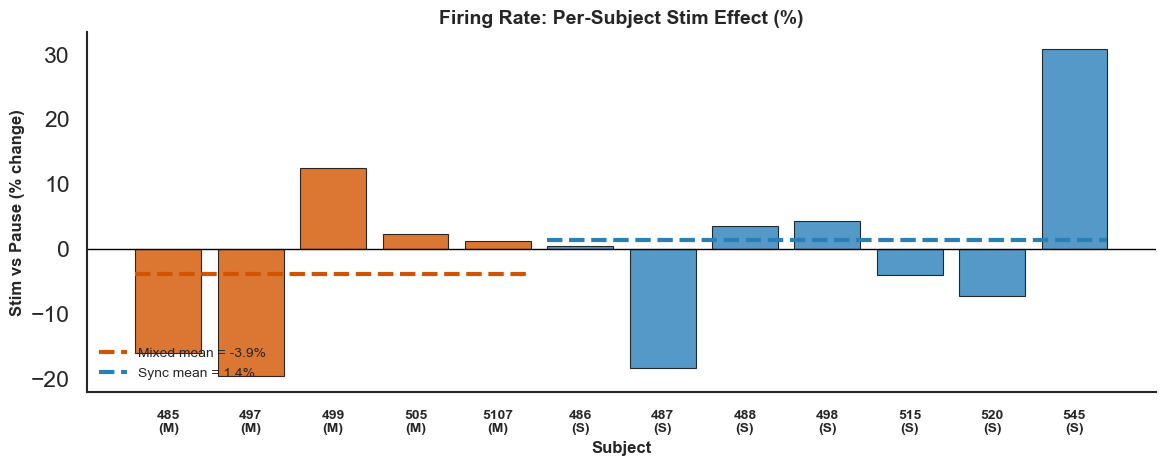


Firing Rate: Per-Subject Stim Effect (%)
  Mixed: mean effect = -3.9%, subjects = ['485', '497', '499', '505', '5107']
  Sync: mean effect = 1.4%, subjects = ['486', '487', '488', '498', '515', '520', '545']


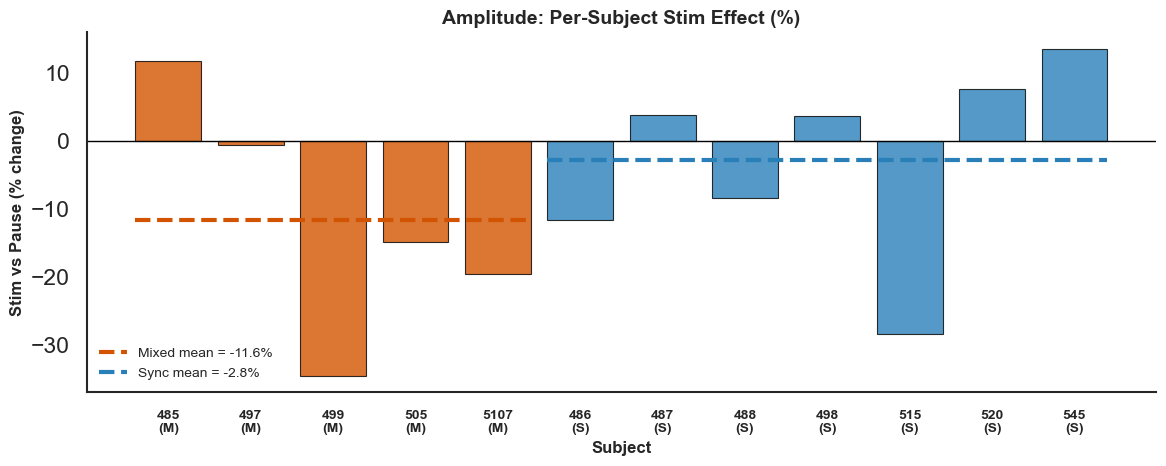


Amplitude: Per-Subject Stim Effect (%)
  Mixed: mean effect = -11.6%, subjects = ['485', '497', '499', '505', '5107']
  Sync: mean effect = -2.8%, subjects = ['486', '487', '488', '498', '515', '520', '545']


In [21]:
def plot_per_subject_stim_effect(df, dv, ylabel, title):
    """
    Bar chart of % change (stim mean vs pause mean) per subject,
    colored by stim type.
    % change = (stim_mean - pause_mean) / pause_mean * 100
    """
    data = df[df['block_type'].isin(['stim', 'pause'])].copy()
    subj_means = data.groupby(['Subject_ID', 'stim_type', 'block_type'])[dv].mean().unstack('block_type')
    subj_means['effect_pct'] = (subj_means['stim'] - subj_means['pause']) / subj_means['pause'] * 100
    subj_means = subj_means.reset_index().sort_values('stim_type')

    color_map = {'M': '#d35400', 'S': '#2980b9'}

    fig, ax = plt.subplots(figsize=(12, 5))

    x_pos = np.arange(len(subj_means))
    colors = [color_map[st] for st in subj_means['stim_type']]

    bars = ax.bar(x_pos, subj_means['effect_pct'], color=colors, edgecolor='black',
                  linewidth=0.8, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=1, zorder=1)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{row.Subject_ID}\n({row.stim_type})"
                        for _, row in subj_means.iterrows()],
                       fontsize=10, fontweight='bold')
    ax.set_xlabel('Subject', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Add group means as horizontal lines
    for stype, color in color_map.items():
        grp = subj_means[subj_means['stim_type'] == stype]
        grp_mean = grp['effect_pct'].mean()
        grp_indices = x_pos[subj_means['stim_type'].values == stype]
        ax.hlines(grp_mean, grp_indices.min() - 0.4, grp_indices.max() + 0.4,
                  colors=color, linewidth=3, linestyle='--', zorder=10,
                  label=f'{"Mixed" if stype == "M" else "Sync"} mean = {grp_mean:.1f}%')

    ax.legend(frameon=False, fontsize=10, loc='lower left')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f'\n{title}')
    for stype in ['M', 'S']:
        grp = subj_means[subj_means['stim_type'] == stype]
        print(f'  {"Mixed" if stype == "M" else "Sync"}: '
              f'mean effect = {grp["effect_pct"].mean():.1f}%, '
              f'subjects = {list(grp["Subject_ID"])}')


plot_per_subject_stim_effect(df_rate, 'firing_rate',
    'Stim vs Pause (% change)', 'Firing Rate: Per-Subject Stim Effect (%)')

plot_per_subject_stim_effect(df_amp, 'amplitude',
    'Stim vs Pause (% change)', 'Amplitude: Per-Subject Stim Effect (%)')